In [1]:
# Loading Basic Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns 

import warnings
warnings.filterwarnings("ignore")

In [2]:
df= pd.read_excel("1607907621_Credit_Card_Customer_Data.xlsx")

In [3]:
df.head()

,Sl_No,Customer Key,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
0,1,87073,100000,2,1,1,0
1,2,38414,50000,3,0,10,9
2,3,17341,50000,7,1,3,4
3,4,40496,30000,5,1,1,4
4,5,47437,100000,6,0,12,3


In [4]:
# shape of the final dataset

print("Our data-set have {} rows and {} columns." .format(df.shape[0], df.shape[1]))

df.head()

Our data-set have 660 rows and 7 columns.


,Sl_No,Customer Key,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
0,1,87073,100000,2,1,1,0
1,2,38414,50000,3,0,10,9
2,3,17341,50000,7,1,3,4
3,4,40496,30000,5,1,1,4
4,5,47437,100000,6,0,12,3


__Exploratory Data Analysis:__

In [5]:
# Summary Statistics

df.describe()

,Sl_No,Customer Key,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
count,660.000000,660.000000,660.000000,660.000000,660.000000,660.000000,660.000000
mean,330.500000,55141.443939,34574.242424,4.706061,2.403030,2.606061,3.583333
std,190.669872,25627.772200,37625.487804,2.167835,1.631813,2.935724,2.865317
min,1.000000,11265.000000,3000.000000,1.000000,0.000000,0.000000,0.000000
25%,165.750000,33825.250000,10000.000000,3.000000,1.000000,1.000000,1.000000
50%,330.500000,53874.500000,18000.000000,5.000000,2.000000,2.000000,3.000000
75%,495.250000,77202.500000,48000.000000,6.000000,4.000000,4.000000,5.000000
max,660.000000,99843.000000,200000.000000,10.000000,5.000000,15.000000,10.000000


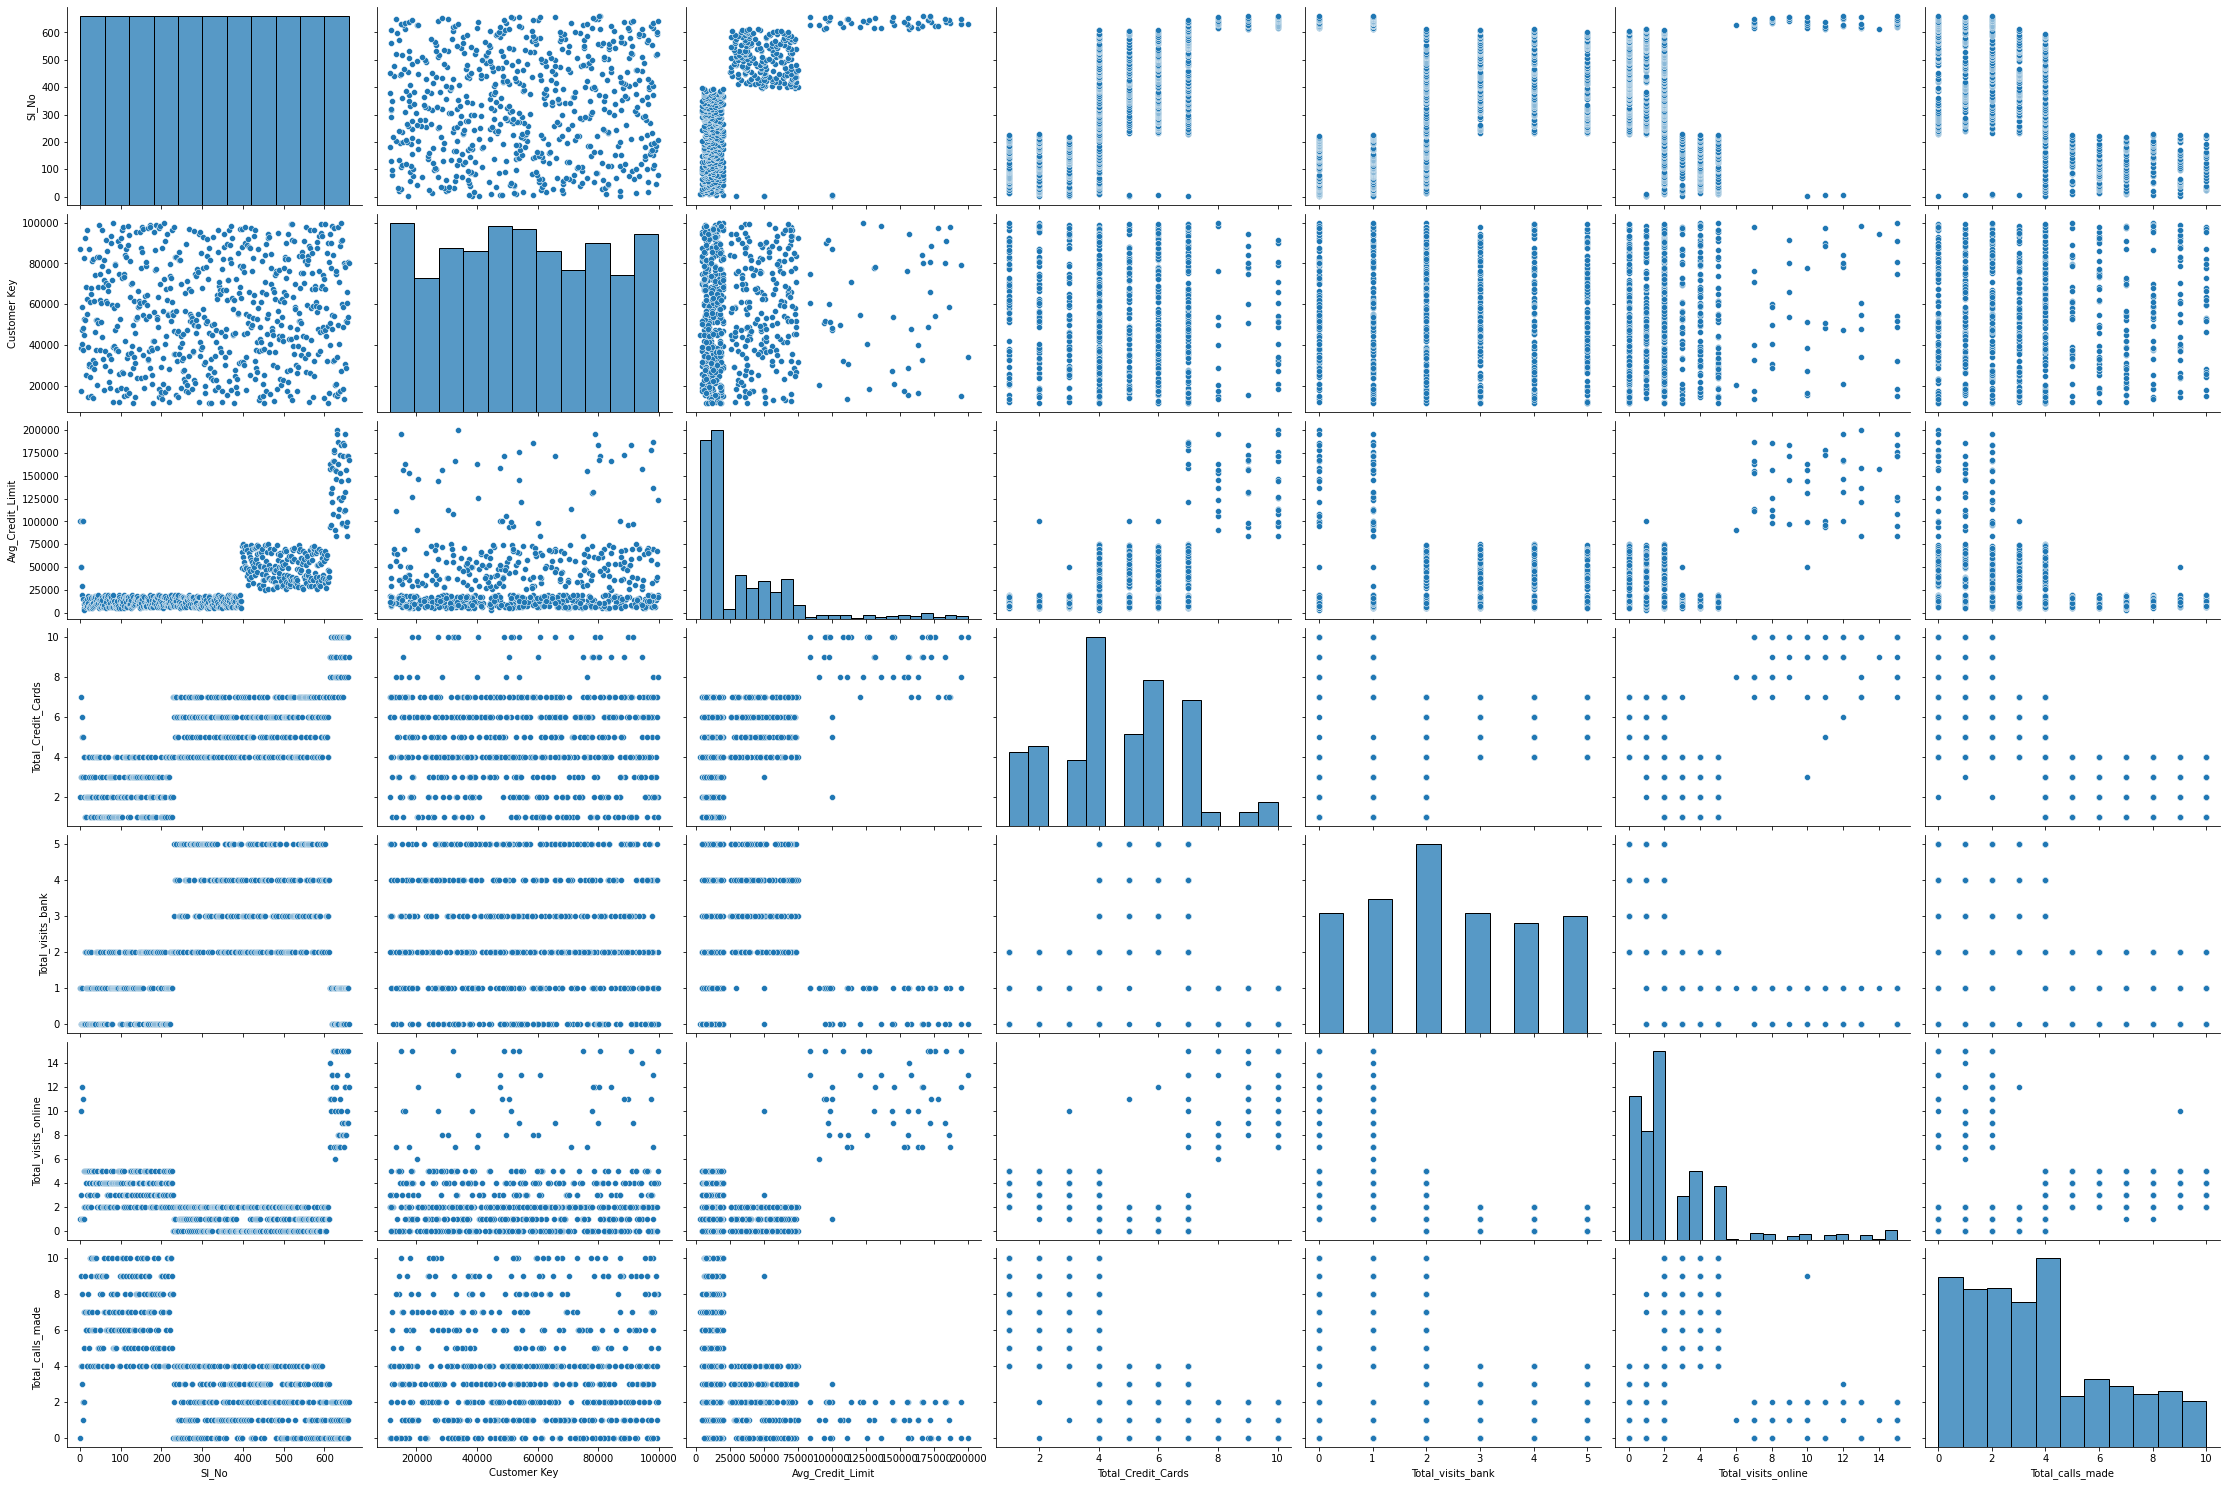

In [6]:
# Pairplot

sns.pairplot(df, height = 3, aspect = 1.5 )

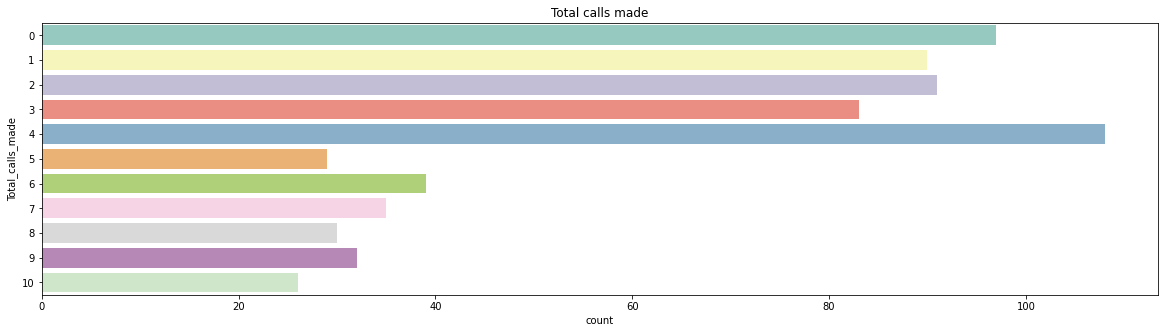

In [7]:
# Countplot of Total_calls_made

def Total_calls_made():
    plt.figure(figsize=(20,5))
    sns.countplot(y = 'Total_calls_made' , data = df, palette="Set3")
    plt.title('Total calls made')
    return(plt.show())
Total_calls_made()

_Mode of Total_calls_made is at 4._

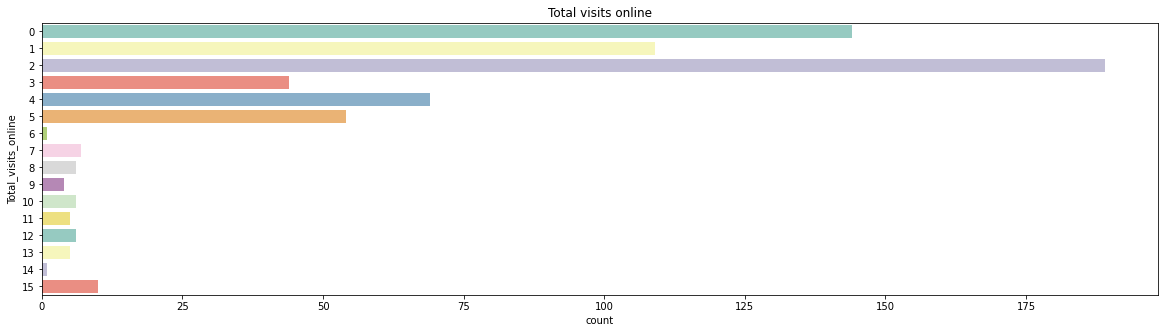

In [8]:
# Countplot of Total_visits_online

def Total_visits_online():
    plt.figure(figsize=(20,5))
    sns.countplot(y = 'Total_visits_online' , data = df, palette="Set3")
    plt.title('Total visits online')
    return(plt.show())
Total_visits_online()

_Mode of Total_visits_online is at 2._

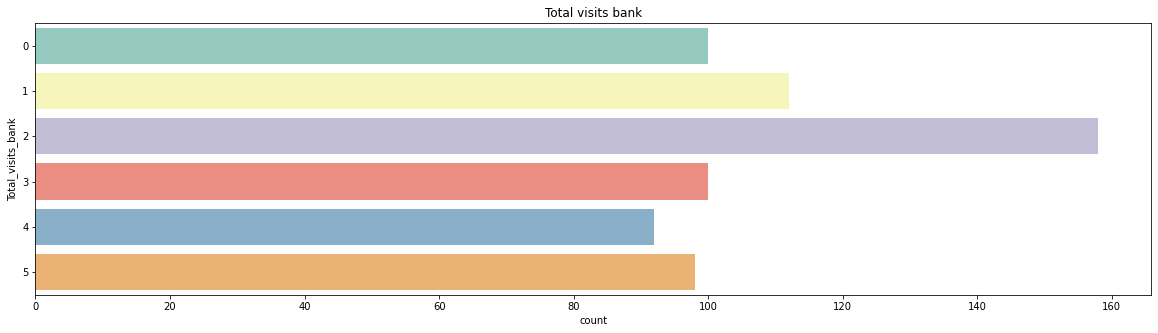

In [9]:
# Countplot of Total_visits_bank

def Total_visits_bank():
    plt.figure(figsize=(20,5))
    sns.countplot(y = 'Total_visits_bank' , data = df, palette="Set3")
    plt.title('Total visits bank')
    return(plt.show())
Total_visits_bank()

_Mode of Total_visits_bank is at 2._

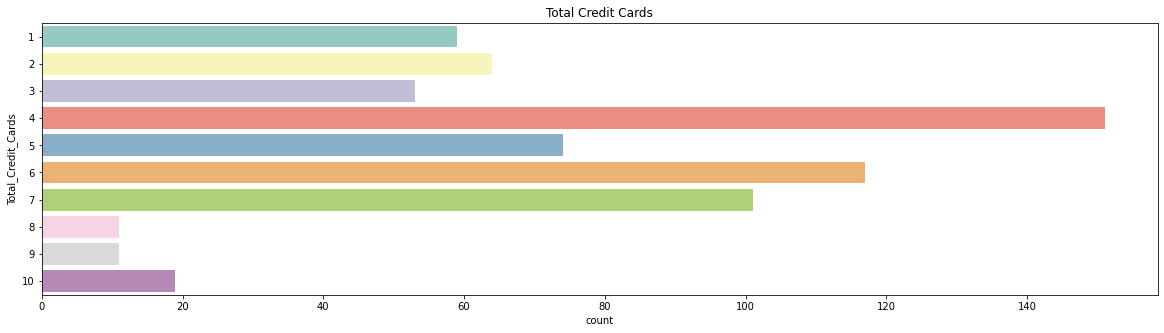

In [10]:
# Countplot of Total_Credit_Cards

def Total_Credit_Cards():
    plt.figure(figsize=(20,5))
    sns.countplot(y = 'Total_Credit_Cards' , data = df, palette="Set3")
    plt.title('Total Credit Cards')
    return(plt.show())
Total_Credit_Cards()

_Mode of Total_Credit_Cards is at 4._

In [11]:
# selcting relevant features for clustering

X = df[['Avg_Credit_Limit', 'Total_Credit_Cards', 'Total_visits_bank','Total_visits_online', 'Total_calls_made']]

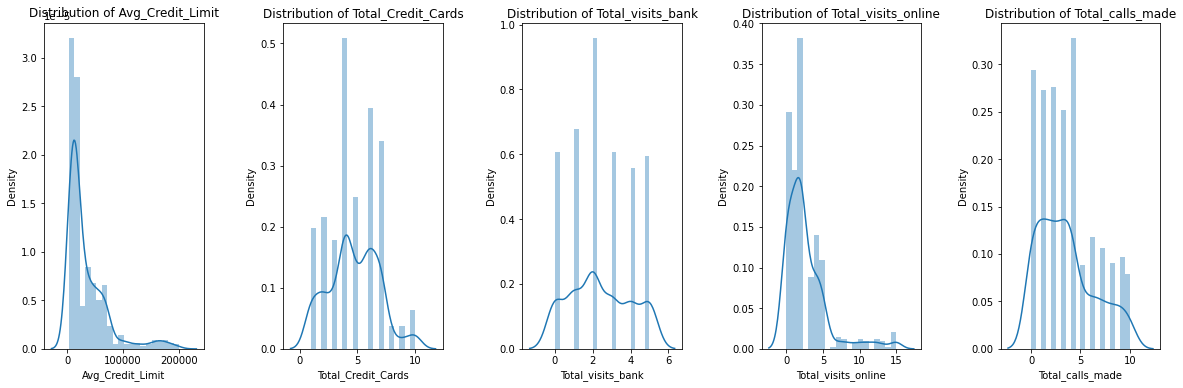

In [12]:
# Data Distribution of the Features

plt.figure(1 , figsize = (20 , 6))
n = 0 
for x in X.columns:
    n += 1
    plt.subplot(1 , 5 , n)
    plt.subplots_adjust(hspace =0.5 , wspace = 0.5)
    sns.distplot(X[x] , bins = 20)
    plt.title('Distribution of {}'.format(x))
plt.show()

_The above features does not falls under Normal Distribution, having right skewness._

__K-Means Clustering:__

In [13]:
from sklearn.cluster import KMeans

inertia = []
for n in range(1 , 11):
    algorithm = (KMeans(n_clusters = n ,init='k-means++', n_init = 10 ,max_iter=300, 
                        tol=0.0001,  random_state= 111  , algorithm='elkan') )
    algorithm.fit(X)
    inertia.append(algorithm.inertia_)

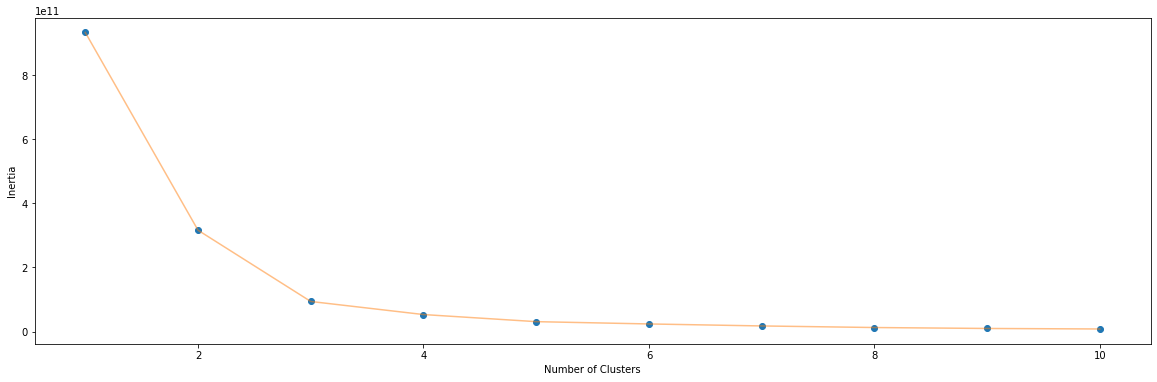

In [14]:
plt.figure(1 , figsize = (20 ,6))
plt.plot(np.arange(1 , 11) , inertia , 'o')
plt.plot(np.arange(1 , 11) , inertia , '-' , alpha = 0.5)
plt.xlabel('Number of Clusters') , plt.ylabel('Inertia')
plt.show()

_The best K value using the elbow method is 5, the number ofclusters formed by KMeans clustering is 5._

In [15]:
kmeans = KMeans(n_clusters=5).fit(X)

df['KMeans_cluster'] = kmeans.labels_

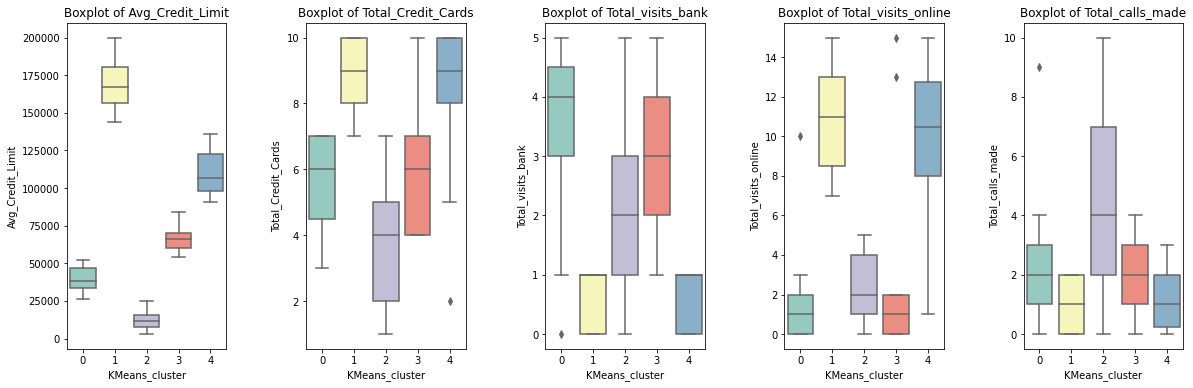

In [16]:
plt.figure(1 , figsize = (20 , 6))
n = 0 

for x in X.columns:
    n += 1
    plt.subplot(1 , 5 , n)
    plt.subplots_adjust(hspace =0.5 , wspace = 0.5)
    sns.boxplot(df["KMeans_cluster"],X[x],palette="Set3")
    plt.title('Boxplot of {}'.format(x))
plt.show()

_The above boxplot shows the presence of very less outliers based on KMeans Clustering._

__Hierarchical clustering:__

In [17]:
from scipy.cluster.hierarchy import dendrogram, linkage, cophenet
from scipy.spatial.distance import pdist

_Method = 'average'_

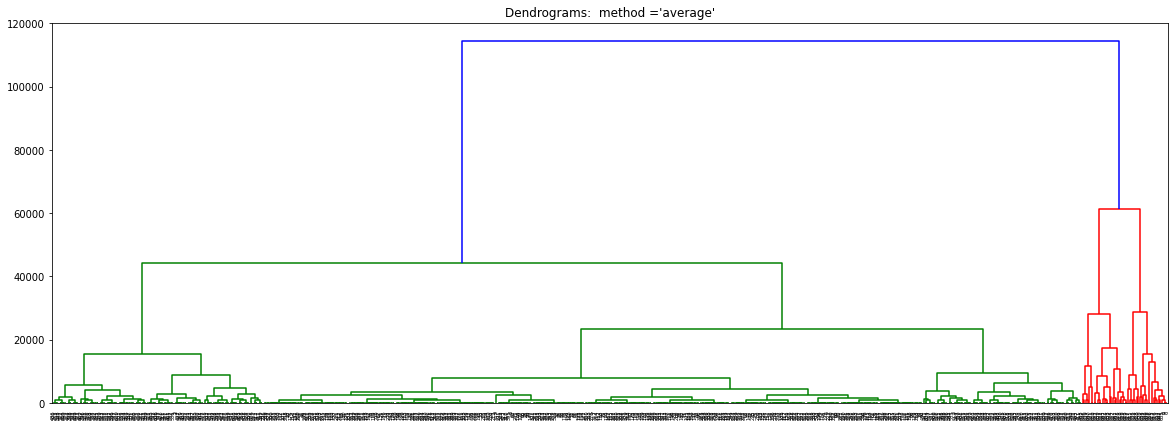

In [18]:
Z = linkage(X, method='average')

plt.figure(figsize=(20, 7))  
plt.title("Dendrograms:  method ='average'")  
dend = dendrogram(Z)

_Number of clusters formed by Hierarchical Clustering when method = 'average' is 5._

In [19]:
c, coph_dists = cophenet(Z, pdist(X))
print("Method = 'average', Cophenetic Coefficient = {}.".format(c))

Method = 'average', Cophenetic Coefficient = 0.9037157730293384.


_Method = 'weighted'_

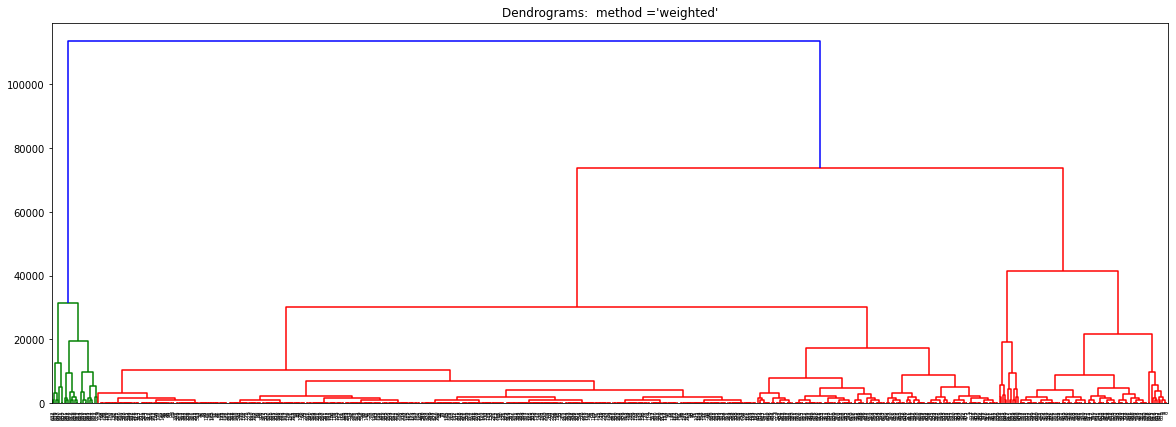

In [20]:
Z = linkage(X, method='weighted')

plt.figure(figsize=(20, 7))  
plt.title("Dendrograms:  method ='weighted'")  
dend = dendrogram(Z)

_Number of clusters formed by Hierarchical Clustering when method = 'weighted' is 5._

In [21]:
c, coph_dists = cophenet(Z, pdist(X))
print("Method = 'weighted', Cophenetic Coefficient = {}.".format(c))

Method = 'weighted', Cophenetic Coefficient = 0.8787603048686384.


_Method = 'ward'_

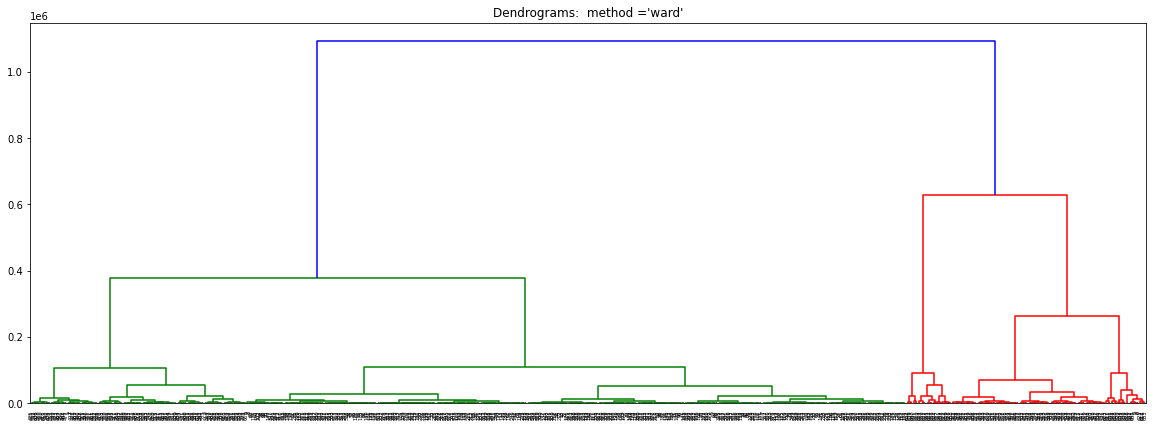

In [22]:
Z = linkage(X, method='ward')

plt.figure(figsize=(20, 7))  
plt.title("Dendrograms:  method ='ward'")  
dend = dendrogram(Z)

_Number of clusters formed by Hierarchical Clustering when method = 'ward' is 5._

In [23]:
c, coph_dists = cophenet(Z, pdist(X))
print("Method = 'ward', Cophenetic Coefficient = {}.".format(c))

Method = 'ward', Cophenetic Coefficient = 0.7380636619071902.


_Method = 'centroid'_

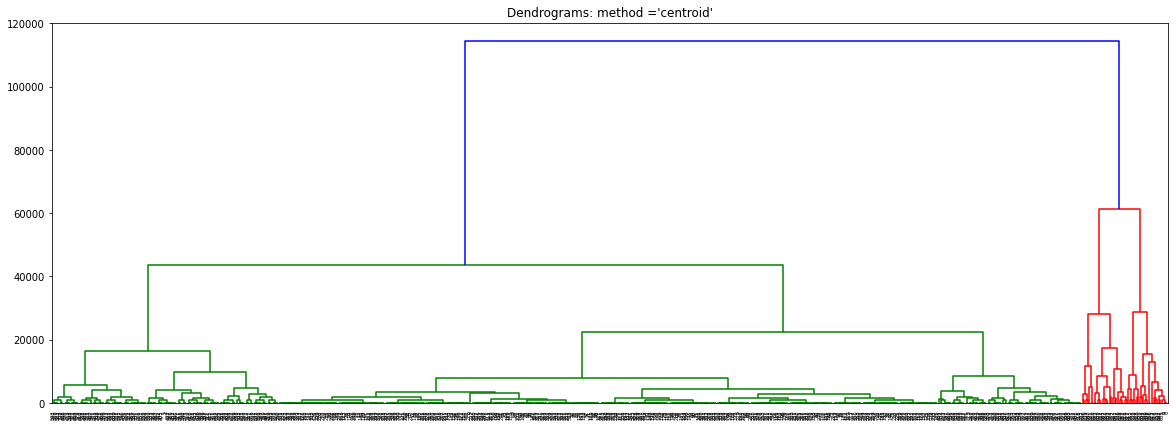

In [24]:
Z = linkage(X, method='centroid')

plt.figure(figsize=(20, 7))  
plt.title("Dendrograms: method ='centroid'")  
dend = dendrogram(Z)

In [25]:
c, coph_dists = cophenet(Z, pdist(X))
print("Method = 'centroid', Cophenetic Coefficient = {}.".format(c))

Method = 'centroid', Cophenetic Coefficient = 0.9037084851657117.


__Best Cophenetic Coefficient = 0.9037157730293384, when method = "average" and numberof clusters formed are 5.__

In [26]:
from sklearn.cluster import AgglomerativeClustering

hierarchical_cluster = AgglomerativeClustering(n_clusters=5, affinity='euclidean', linkage='ward')
hierarchical_cluster.fit_predict(X)

df['Hierarchical_cluster'] = hierarchical_cluster.labels_

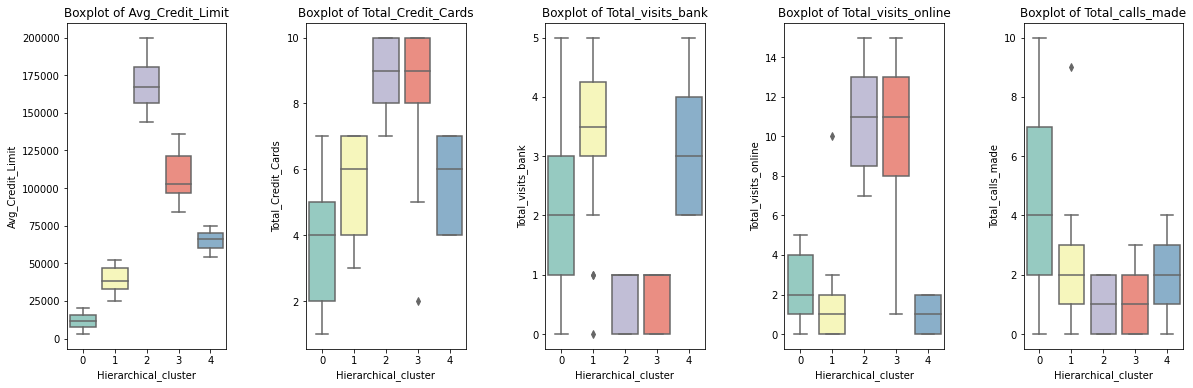

In [27]:
plt.figure(1 , figsize = (20 , 6))
n = 0 
for x in X.columns:
    n += 1
    plt.subplot(1 , 5 , n)
    plt.subplots_adjust(hspace =0.5 , wspace = 0.5)
    sns.boxplot(df["Hierarchical_cluster"],X[x],palette="Set3")
    plt.title('Boxplot of {}'.format(x))
plt.show()

_The above boxplot shows the presence of very less outliers based on Hierarchical Clustering._

__Silhouette score:__ 

In [28]:
# Silhouette Score of Hierarchical Clustering

from sklearn.metrics import silhouette_score

s1 = silhouette_score(X, hierarchical_cluster.fit_predict(X))

print("Silhouette score of hierarchical clustering is {:.3f}.".format(s1))

Silhouette score of hierarchical clustering is 0.707.


In [29]:
# Silhouette Score of KMeans Clustering

kmean_cluster = KMeans(n_clusters = 5)

s2 = silhouette_score(X, kmean_cluster.fit_predict(X))

print("Silhouette score of KMeans clustering is {:.3f}.".format(s2))

Silhouette score of KMeans clustering is 0.709.


In [30]:
# Average Silhouette Score for both methods

print("Average Silhouette Score for both methods is {:.3f}." .format((s1+s2)/2))

Average Silhouette Score for both methods is 0.708.


__Based on the Silhouette Score of the two models:__

*   KMean Clustering: 0.709
*   Hierarchical Clustering: 0.708

__KMean performed better Hierarchical.__

